In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Zadanie 6

Family Size with highest survival rate: 4.0 with rate 0.72
   Family_Size  Survival_Rate
0            1       0.303538
1            2       0.552795
2            3       0.578431
3            4       0.724138
4            5       0.200000
5            6       0.136364
6            7       0.333333
7            8       0.000000
8           11       0.000000


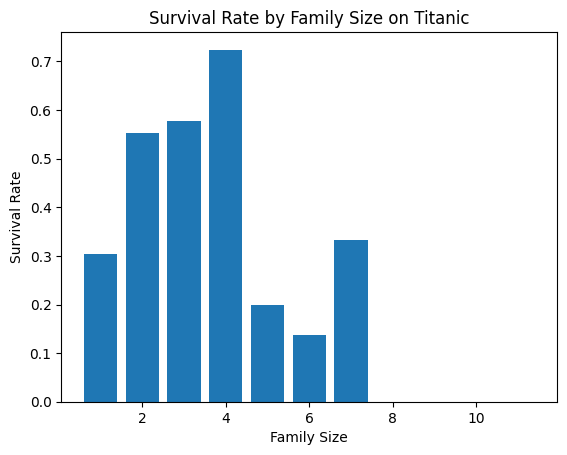

In [6]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

titanic['Family_Size'] = titanic['SibSp'] + titanic['Parch'] + 1

family_survival_rate = titanic.groupby('Family_Size')['Survived'].mean().reset_index()
family_survival_rate.columns = ['Family_Size', 'Survival_Rate']

max_survival_size = family_survival_rate.loc[family_survival_rate['Survival_Rate'].idxmax()]
print(f"Family Size with highest survival rate: {max_survival_size['Family_Size']} with rate {max_survival_size['Survival_Rate']:.2f}")
print(family_survival_rate)

plt.bar(family_survival_rate['Family_Size'], family_survival_rate['Survival_Rate'])
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Family Size on Titanic')
plt.show()


Zadanie 7 *

In [45]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing(as_frame=True)
california_df = california.frame

number_of_beans = 10

california_df['Region'] = pd.cut(california_df['Latitude'], bins=number_of_beans ).astype(str)  + " | " + pd.cut(california_df['Longitude'], bins=number_of_beans).astype(str)

region_prices = round(california_df.groupby(['Region'])['MedHouseVal'].mean(), 2).reset_index()
region_prices = region_prices.sort_values(by='MedHouseVal', ascending=False).head(5)
region_prices

,Region,MedHouseVal
4,"(32.531, 33.481] | (-119.33, -118.326]",3.51
37,"(37.245, 38.186] | (-123.346, -122.342]",3.27
24,"(35.363, 36.304] | (-122.342, -121.338]",3.20
10,"(33.481, 34.422] | (-120.334, -119.33]",3.10
16,"(34.422, 35.363] | (-120.334, -119.33]",3.08


Zadanie 10

In [43]:
def iqr_func(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    return round(Q3 - Q1, 2)  

iqr_by_region = california_df.groupby('Region')['MedHouseVal'].apply(iqr_func).reset_index()
iqr_by_region.columns = ['Region', 'IQR_MedHouseVal']   
iqr_by_region.head(10)

,Region,IQR_MedHouseVal
0,"(32.531, 33.481] | (-115.314, -114.31]",0.13
1,"(32.531, 33.481] | (-116.318, -115.314]",0.26
2,"(32.531, 33.481] | (-117.322, -116.318]",1.01
3,"(32.531, 33.481] | (-118.326, -117.322]",1.52
4,"(32.531, 33.481] | (-119.33, -118.326]",0.64
5,"(33.481, 34.422] | (-115.314, -114.31]",0.24
6,"(33.481, 34.422] | (-116.318, -115.314]",0.33
7,"(33.481, 34.422] | (-117.322, -116.318]",0.60
8,"(33.481, 34.422] | (-118.326, -117.322]",1.00
9,"(33.481, 34.422] | (-119.33, -118.326]",1.82
